## SENTIMENT SCORING WITH VADER AND TEXTBLOB

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from langdetect import detect
from textblob import TextBlob
import nltk
import unicodedata
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
df = pd.read_csv("cleaned_reviews.csv")
analyzer = SentimentIntensityAnalyzer()

In [3]:
print(TextBlob("This appa is very good and easy to use").sentiment)
print(analyzer.polarity_scores("This appa is very bad crashes"))

Sentiment(polarity=0.6716666666666666, subjectivity=0.8066666666666668)
{'neg': 0.431, 'neu': 0.569, 'pos': 0.0, 'compound': -0.5849}


In [4]:
df["sentiment_tb"] = df["content_clean"].apply(lambda x:
TextBlob(x).sentiment.polarity)                                               

In [5]:
print(df[['sentiment_tb']])

     sentiment_tb
0        1.000000
1        0.000000
2       -0.375000
3       -0.700000
4        0.000000
..            ...
313      0.700000
314      0.050000
315      0.666667
316      0.433333
317      0.600000

[318 rows x 1 columns]


In [6]:
df["sentiment_vader"] = df["content_clean"].apply(lambda x:
analyzer.polarity_scores(x)['compound']) 

In [22]:
def label_sentiment(score):
    if score > 0.5:
        return "positive"
    elif score < -0.5:
        return "negative"
    else:
        return "neutral"

In [23]:
df["sentiment_tb_label"] = df["sentiment_tb"].apply(label_sentiment)
df["sentiment_vader_label"] = df["sentiment_vader"].apply(label_sentiment)

In [24]:
print(df["sentiment_tb_label"].value_counts())
print(df["sentiment_vader_label"].value_counts())

sentiment_tb_label
neutral     220
positive     86
negative     12
Name: count, dtype: int64
sentiment_vader_label
neutral     174
positive    111
negative     33
Name: count, dtype: int64


In [25]:
sentiment_col = 'sentiment_vader'
label_col = 'sentiment_vader_label'

In [26]:
bank_sentiment = (
    df.groupby('bank')
[sentiment_col]
    .mean()
    .reset_index()
    .sort_values(by=sentiment_col, ascending=False)
)
print(bank_sentiment)

     bank  sentiment_vader
2  Dashen         0.361293
1     CBE         0.295231
0     BOA         0.044744


<function matplotlib.pyplot.show(close=None, block=None)>

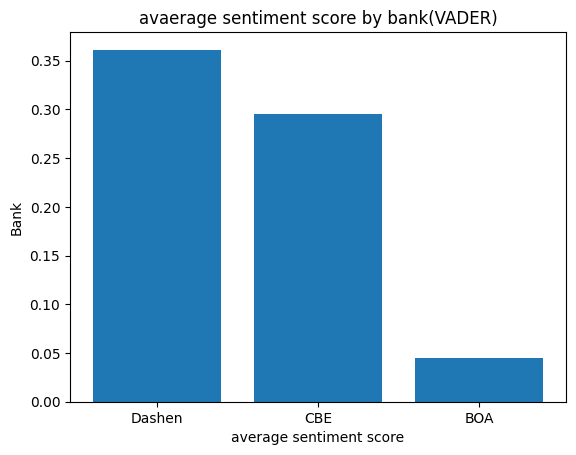

In [27]:
plt.figure()
plt.bar(bank_sentiment['bank'], bank_sentiment[sentiment_col])
plt.title('avaerage sentiment score by bank(VADER)')
plt.ylabel('Bank')
plt.xlabel('average sentiment score')
plt.show

In [28]:
positive_rate = (
    df[df[label_col] == 'positive']
    .groupby('bank')
    .size()
    / df.groupby('bank').size()
    * 100
).reset_index(name='positive_percentage')
print(positive_rate.sort_values(by='positive_percentage', ascending=False))

     bank  positive_percentage
2  Dashen            46.774194
1     CBE            35.483871
0     BOA            19.801980


In [29]:
def combined_label(row):
    votes = [row["sentiment_vader"], row["sentiment_tb"]]
    # prefer Vader if tie
    if votes.count("positive") > votes.count("negative"):
        return "positive"
    elif votes.count("negative") > votes.count("positive"):
        return "negative"
    else:
        return row["sentiment_vader"]

In [30]:
df["sentiment_combined"] = df.apply(combined_label, axis=1)

In [31]:
df.to_csv("scored_reviews.csv", index=False)
print("Saved scored_reviews.csv")

Saved scored_reviews.csv


In [32]:
df

,bank,app_id,review_id,user_name,score,content,date,thumbs_up,content_clean,lang,sentiment_tb,sentiment_vader,sentiment_tb_label,sentiment_vader_label,sentiment_combined
0,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0,best app of the year,en,1.000000,0.6369,positive,positive,0.6369
1,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0,it constantly bugs and doesnt open what is the...,en,0.000000,0.0000,neutral,neutral,0.0000
2,BOA,com.boa.boaMobileBanking,65eb86df-c336-4035-bd1d-a014d89f4f67,ayne abreham,1,"please fix the bug this app does not work, it ...",2025-12-05 17:26:55.954000+00:00,1,"please fix the bug this app does not work, it ...",en,-0.375000,-0.6634,neutral,negative,-0.6634
3,BOA,com.boa.boaMobileBanking,7a4c3729-98fc-4bda-a031-835cf4594d78,welsh yohans,1,what a bad app... cant even learn from CBE ......,2025-12-02 08:12:23.198000+00:00,0,what a bad app... cant even learn from CBE ......,en,-0.700000,-0.1531,negative,neutral,-0.1531
4,BOA,com.boa.boaMobileBanking,d27d3172-fb10-492e-af66-8923ee7a2cfb,Afomi,1,it stuck everytime when i use it . the app won...,2025-12-02 04:43:05.548000+00:00,0,it stuck everytime when i use it . the app won...,en,0.000000,-0.2500,neutral,neutral,-0.2500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,Dashen,com.dashen.dashensuperapp,04461449-8fd8-4684-8b12-1bc3aee7f6f2,Fitsum Mardu,4,"Good improvements after the Sep 25, 2025 update.",2025-09-29 07:17:49.705000+00:00,4,"Good improvements after the Sep 25, 2025 update.",en,0.700000,0.6369,positive,positive,0.6369
314,Dashen,com.dashen.dashensuperapp,9a6e8134-27c5-45f1-8dae-6c6fb1827281,Shewangizaw Liulseged,1,I have one issue though what if the mobile pho...,2025-09-28 16:50:25.233000+00:00,347,I have one issue though what if the mobile pho...,en,0.050000,-0.7788,neutral,negative,-0.7788
315,Dashen,com.dashen.dashensuperapp,a2779b7b-ad8d-420f-a4d4-d1e4ec4212d8,Suda Ya fatu,5,Dashen super app is the best all ethiopian ban...,2025-09-27 17:16:36.601000+00:00,2,Dashen super app is the best all ethiopian ban...,en,0.666667,0.8442,positive,positive,0.8442
316,Dashen,com.dashen.dashensuperapp,90dfd168-3d83-4e21-87ee-6500a304e586,Kelbesa Gonfa,5,App That makes cashless society in our century...,2025-09-27 12:05:30.600000+00:00,1,App That makes cashless society in our century...,en,0.433333,0.4404,neutral,neutral,0.4404


In [33]:
neg_reviews = df[df['sentiment_tb'] < 0]
pos_reviews = df[df['sentiment_tb'] > 0]

In [34]:
neg_words = [word for review in neg_reviews['content_clean'] for word in TextBlob(review).words]

pain_points = Counter(neg_words).most_common(20)

pos_words = [word for review in neg_reviews['content_clean'] for word in TextBlob(review).words]

pos_drivers = Counter(pos_words).most_common(20)
print("Top pain_points:", pain_points)
print("Top positive drivers:", pos_drivers)

Top pain_points: [('the', 46), ('app', 32), ('it', 30), ('is', 28), ('to', 25), ('and', 20), ('I', 19), ('not', 15), ('a', 15), ('very', 13), ('for', 13), ('of', 12), ('this', 11), ('worst', 11), ("n't", 11), ('bank', 9), ('ever', 9), ('in', 9), ('are', 9), ('does', 8)]
Top positive drivers: [('the', 46), ('app', 32), ('it', 30), ('is', 28), ('to', 25), ('and', 20), ('I', 19), ('not', 15), ('a', 15), ('very', 13), ('for', 13), ('of', 12), ('this', 11), ('worst', 11), ("n't", 11), ('bank', 9), ('ever', 9), ('in', 9), ('are', 9), ('does', 8)]


In [35]:
df['content_clean'].head(269)

0                                   best app of the year
1      it constantly bugs and doesnt open what is the...
2      please fix the bug this app does not work, it ...
3      what a bad app... cant even learn from CBE ......
4      it stuck everytime when i use it . the app won...
                             ...                        
264    it has improved very much lately its working m...
265    I just updated my app to the latest version an...
266                                        it's too slow
267    Before the recent update, this app was great. ...
268    This might be the worst banking app I've ever ...
Name: content_clean, Length: 269, dtype: object

In [36]:
df['content_clean'].str.len().describe()

count    318.000000
mean      83.342767
std       97.794216
min        3.000000
25%       20.000000
50%       44.000000
75%      107.000000
max      497.000000
Name: content_clean, dtype: float64